# 01 - Exploratory Data Analysis

Objective:
Understand the characteristics of the Delhi Urban Heat Dataset generated during Phase 1 and identify relationships between land surface temperature and environmental predictors.

### Import Required Libraries

The following libraries are used for data manipulation and visualization during exploratory analysis.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)

### Load the Processed Dataset

The dataset contains grid-level thermal and environmental indicators generated during Phase 1.

In [ ]:
df = pd.read_csv("../data/processed/delhi_heat_dataset_v1.csv")

### Inspect Dataset Structure

Examine the dimensions, sample records, and data types of the exported dataset.

In [5]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (31932, 7)


,system:index,latitude,longitude,mean_lst,mean_ndbi,mean_ndvi,.geo
0,"34359,13202",28.408898,77.164160,22.599892,-0.045069,0.188354,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
1,"34360,13202",28.408898,77.166406,17.924864,-0.016179,0.129377,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
2,"34361,13202",28.408898,77.168652,25.920861,-0.021533,0.149206,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
3,"34362,13202",28.408898,77.170897,37.349696,-0.046880,0.184968,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
4,"34358,13203",28.410874,77.161914,31.636029,-0.028314,0.119132,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31932 entries, 0 to 31931
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   system:index  31932 non-null  str    
 1   latitude      31932 non-null  float64
 2   longitude     31932 non-null  float64
 3   mean_lst      31932 non-null  float64
 4   mean_ndbi     31932 non-null  float64
 5   mean_ndvi     31932 non-null  float64
 6   .geo          31932 non-null  str    
dtypes: float64(5), str(2)
memory usage: 1.7 MB


In [7]:
df.columns.tolist()

['system:index',
 'latitude',
 'longitude',
 'mean_lst',
 'mean_ndbi',
 'mean_ndvi',
 '.geo']

In [8]:
df = df.drop(columns=['system:index', '.geo'])

print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['latitude', 'longitude', 'mean_lst', 'mean_ndbi', 'mean_ndvi']


### Check for Missing Values

Missing observations can influence model training and evaluation.

In [9]:
df.isnull().sum()

latitude     0
longitude    0
mean_lst     0
mean_ndbi    0
mean_ndvi    0
dtype: int64

### Summary Statistics

Compute descriptive statistics to understand the range and variability of the variables.

In [10]:
df.describe()

,latitude,longitude,mean_lst,mean_ndbi,mean_ndvi
count,31932.000000,31932.000000,31932.000000,31932.000000,31932.000000
mean,28.646661,77.108804,42.660518,-0.048002,0.172486
std,0.108627,0.114721,4.928169,0.044906,0.062553
min,28.408898,76.834029,15.006653,-0.238950,0.009721
25%,28.560890,77.020430,40.179872,-0.079954,0.124822
50%,28.637789,77.116998,42.761849,-0.044410,0.167220
75%,28.730388,77.197847,45.545346,-0.013512,0.216593
max,28.883881,77.337086,57.646485,0.125919,0.378341


### Distribution of Variables

Visualize the distributions of land surface temperature, vegetation intensity, and built-up intensity.

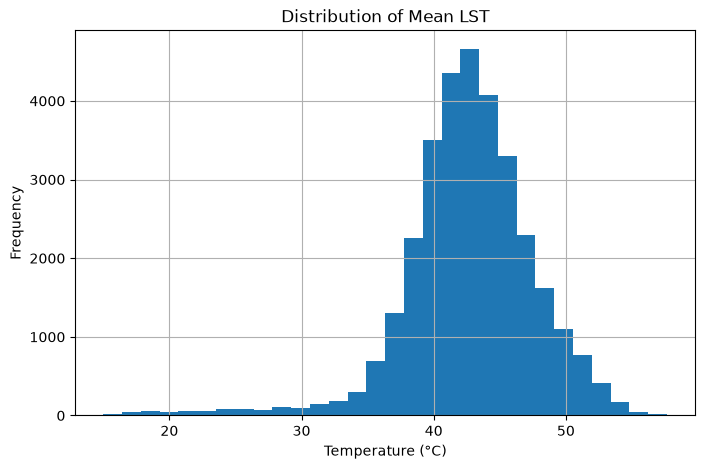

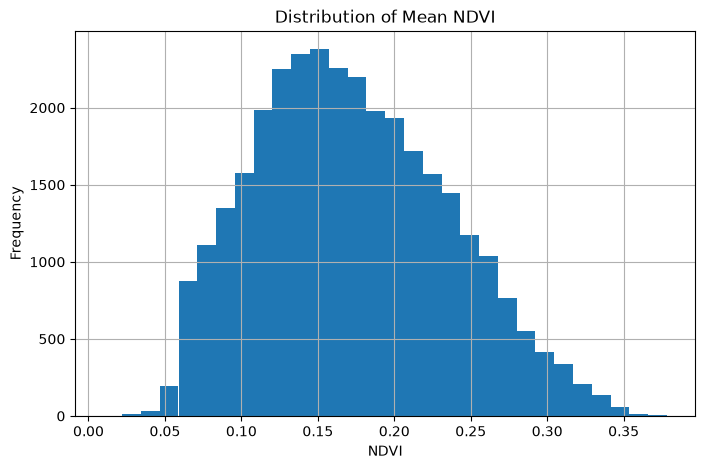

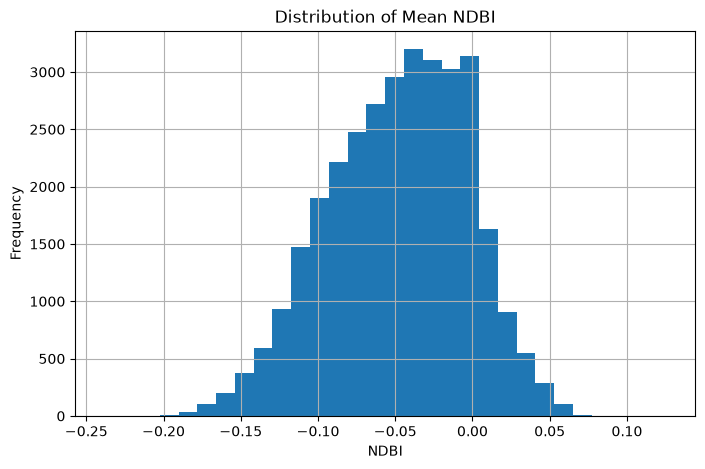

In [11]:
df['mean_lst'].hist(bins=30)
plt.title('Distribution of Mean LST')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

df['mean_ndvi'].hist(bins=30)
plt.title('Distribution of Mean NDVI')
plt.xlabel('NDVI')
plt.ylabel('Frequency')
plt.show()

df['mean_ndbi'].hist(bins=30)
plt.title('Distribution of Mean NDBI')
plt.xlabel('NDBI')
plt.ylabel('Frequency')
plt.show()

### Correlation Between Variables

Evaluate linear relationships between thermal and environmental indicators.

In [12]:
df[['mean_lst', 'mean_ndvi', 'mean_ndbi']].corr()

,mean_lst,mean_ndvi,mean_ndbi
mean_lst,1.000000,-0.371303,0.588498
mean_ndvi,-0.371303,1.000000,-0.863546
mean_ndbi,0.588498,-0.863546,1.000000


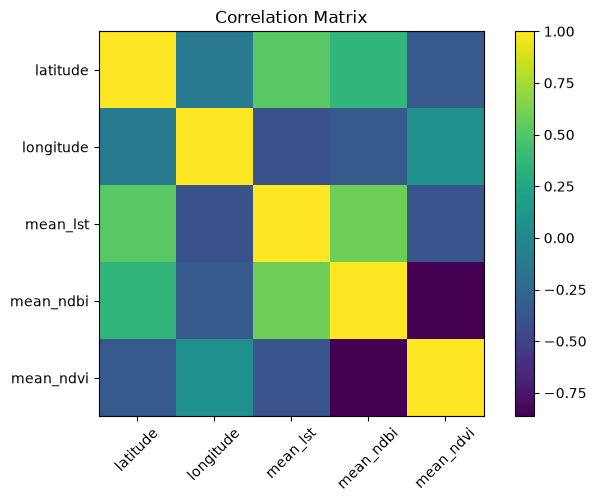

In [13]:
corr = df.corr()

plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Matrix')
plt.show()

## Key Findings

- The dataset contains 31,932 grid-level observations.
- No missing values were detected across the exported variables.
- Land Surface Temperature (LST) exhibits a near-normal distribution centered around approximately 42–43°C.
- NDVI shows a moderate negative correlation with LST (r ≈ -0.37), suggesting that vegetated areas tend to experience lower surface temperatures.
- NDBI demonstrates a moderate positive correlation with LST (r ≈ 0.59), indicating that built-up intensity is associated with elevated temperatures.
- NDVI and NDBI are strongly negatively correlated (r ≈ -0.86), reflecting the inverse relationship between vegetation cover and urban development.

## Conclusion

The exploratory analysis suggests that the Phase 1 dataset is complete, internally consistent, and suitable for predictive modeling. Preliminary relationships indicate that built-up intensity contributes positively to urban heat, whereas vegetation exhibits a cooling association. These observations provide motivation for the machine learning analyses conducted in subsequent phases.

## Correlation Analysis

This section examines relationships between variables in the dataset.
Particular attention is given to how NDVI and NDBI relate to Land Surface Temperature (LST).


In [14]:
corr = df.corr(numeric_only=True)

corr

,latitude,longitude,mean_lst,mean_ndbi,mean_ndvi
latitude,1.000000,-0.102960,0.519776,0.365998,-0.333764
longitude,-0.102960,1.000000,-0.404122,-0.334826,0.069707
mean_lst,0.519776,-0.404122,1.000000,0.588498,-0.371303
mean_ndbi,0.365998,-0.334826,0.588498,1.000000,-0.863546
mean_ndvi,-0.333764,0.069707,-0.371303,-0.863546,1.000000


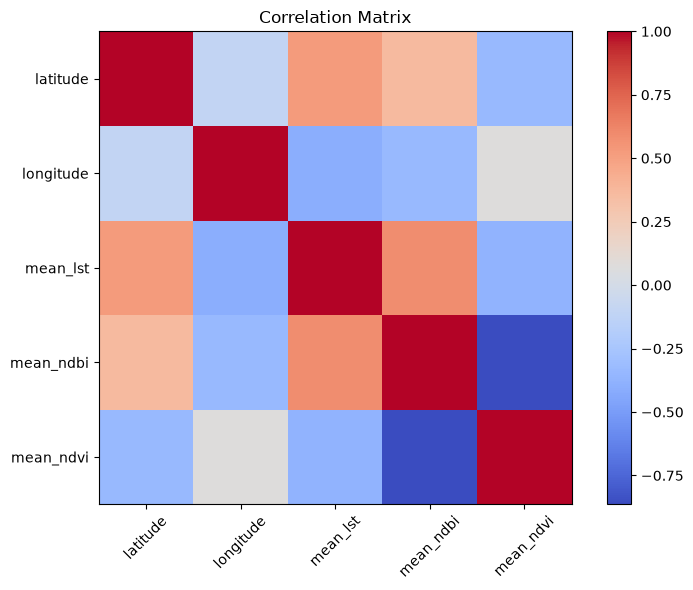

In [15]:
plt.figure(figsize=(8,6))

plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

## Spatial Distribution of Heat

This visualization shows the spatial distribution of Land Surface Temperature across Delhi.
Hotspots may indicate areas with high built-up intensity and limited vegetation cover.

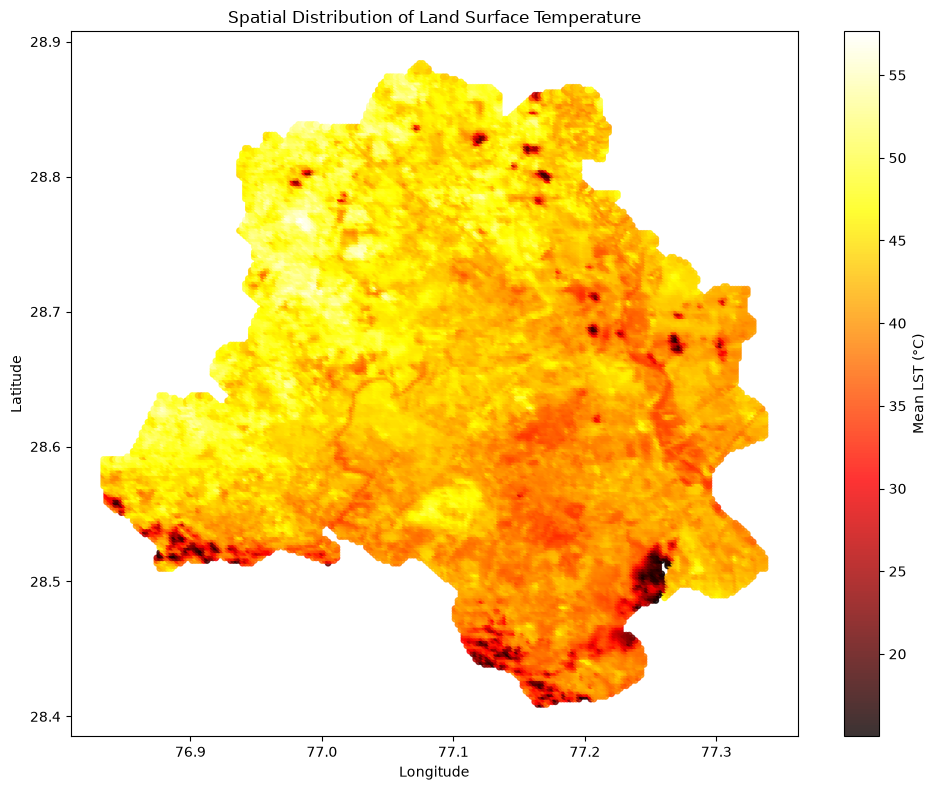

In [18]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['mean_lst'],
    cmap='hot',
    s=15,        # slightly smaller
    alpha=0.8,  # slight transparency
)

plt.colorbar(scatter, label='Mean LST (°C)')

plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.title('Spatial Distribution of Land Surface Temperature')

plt.tight_layout()

plt.show()

## Outlier Detection

Boxplots are used to identify potential outliers within key variables.
Extreme values may influence subsequent modeling stages.

/tmp/ipykernel_63832/1242396848.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[var], vert=False)


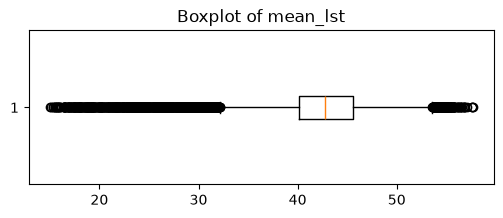

/tmp/ipykernel_63832/1242396848.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[var], vert=False)


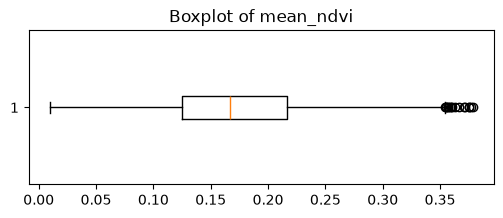

/tmp/ipykernel_63832/1242396848.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[var], vert=False)


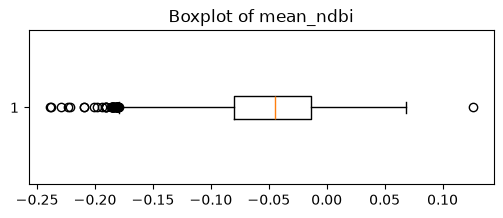

In [19]:
variables = ['mean_lst', 'mean_ndvi', 'mean_ndbi']

for var in variables:
    plt.figure(figsize=(6,2))

    plt.boxplot(df[var], vert=False)

    plt.title(f'Boxplot of {var}')

    plt.show()

## Key Observations

- The dataset contains no missing values.
- NDVI exhibits a negative correlation with LST.
- NDBI exhibits a positive correlation with LST.
- Distinct thermal hotspots are visible across Delhi.
- Cooler regions are associated with increased vegetation cover.
- Several outliers exist and should be considered during model development.